## Notebook E-tivity 2 CE4021 Linear Regression

Student name: David Sheridan

Student ID: 24300446

<hr style="border:2px solid gray"> </hr>

## Imports

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

If you believe required imports are missing, please contact your moderator.

<hr style="border:2px solid gray"> </hr>

## Reference Implementation

In [18]:
def linreg_weights(X,y):
    # Calculation of weights using pseudo-inverse. Note that X needs to contain the bias of 1
    return np.linalg.inv((X.T.dot(X))).dot(X.T).dot(y)

In [20]:
def linreg_predict(w,X):
    # Calculation of outputs given weights and data (X). Note that X needs to contain the bias of 1. 
    out=[]
    for x in X:
        out.append(w.T.dot(x))
    return np.array(out)

Load data from file (including bias of 1)

In [23]:
data = np.loadtxt('lr_data.csv', delimiter=',')
X = data[:,0:2]
y= [[data[i,2]] for i in range(0,len(data[:,2]))]

Apply data to linear regression algorithm to obtain weights

In [25]:
weights = linreg_weights(X,y)
weights

array([[-99.46431881],
       [564.20389249]])

(0.0, 3.0, -100.0, 1500.0)

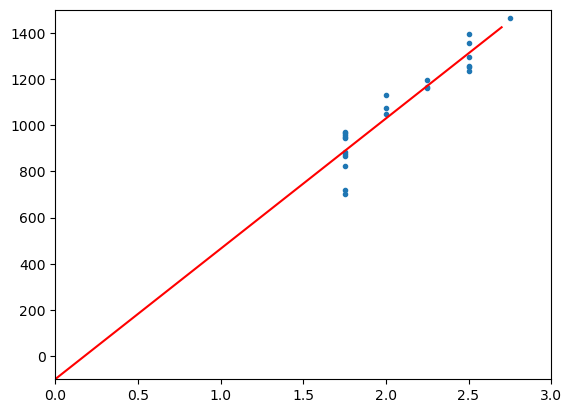

In [26]:
ind = np.arange(0,2.8,0.1)
plt.plot(X[:,1],y,'.')
plt.plot(ind, ind*weights[1]+weights[0],'r')
plt.axis([0, 3, -100, 1500])

<hr style="border:2px solid gray"> </hr>

## Task

You may add as many cells as you require to complete this task.

TASK 1

In [45]:
#1 Defining matrix manipulation functions:

#a Matrix Transpose
def matrix_transpose(X): #returns the transpose of a matrix, 'X' is a matrix
    return [list(row) for row in zip(*X)] #transposed matrix

#b Matrix Multiplication
def matrix_multiply(A,B): #multiplies two matrices using zip(), A = first matrix, B = second matrix
    return  [[sum(a * b for a,b in zip(A_row, B_col)) for B_col in zip(*B)] for A_row in A]
    return result #result of matrix A*B

#c 2x2 Matrix Inversion
def matrix_inverse_2x2(M):#calculates inverse of 2x2 matrix, 2x2 = 2x2 matrix

    if len(M) != 2 or len(M[0]) != 2 or len(M[1]) != 2: #ensure that it is 2x2
        raise ValueError("Please input a 2x2 matrix to use this function")
        
    det = M[0][0] * M[1][1] - M[0][1] * M[1][0] #calculates determinant
    
    if det == 0:
        raise ValueError("Matrix cannot be inverted")
        
    inverse = [[M[1][1] / det, -M[0][1] / det],
               [-M[1][0] / det, M[0][0] /det]] #calculate inverse
    
    return inverse

#d Fit Function to Calculate Weights
def fit(X,y): #function to fit linear regression model
    X_T = matrix_transpose(X) #1 - transpose input matrix X
    
    XTX = matrix_multiply(X_T, X) #2 - Multiply transposed matrix by X
    
    XTX_inv = matrix_inverse_2x2(XTX) #3 - Calculate inverse of matrix 'X^T by X'
    
    XTy = matrix_multiply(X_T, y) #4 - Mulitply transposed matrix by output vector y
    
    w = matrix_multiply(XTX_inv, XTy) #5 - Calculate final weight w, which guves best-fit line for data
    
    return w #weight vector

#e Prediction function to predict outputs based on weights
def predict(w, X):
    predictions = matrix_multiply(X, w) #multiply input data X (matrix) by by weight vector w
    return predictions #predicted output values


#Test in  code:

if __name__ == "__main__":
    
    X = [[1, 1],
         [1, 2],
         [1, 3]]
    
    y = [[1],
         [2],
         [3]]
    
    weights = fit(X, y)
    print("Weights:", weights)
    
    predictions = predict(weights, X)
    print("Predictions", predictions)



Weights: [[0.0], [1.0]]
Predictions [[1.0], [2.0], [3.0]]


Manual Test: 
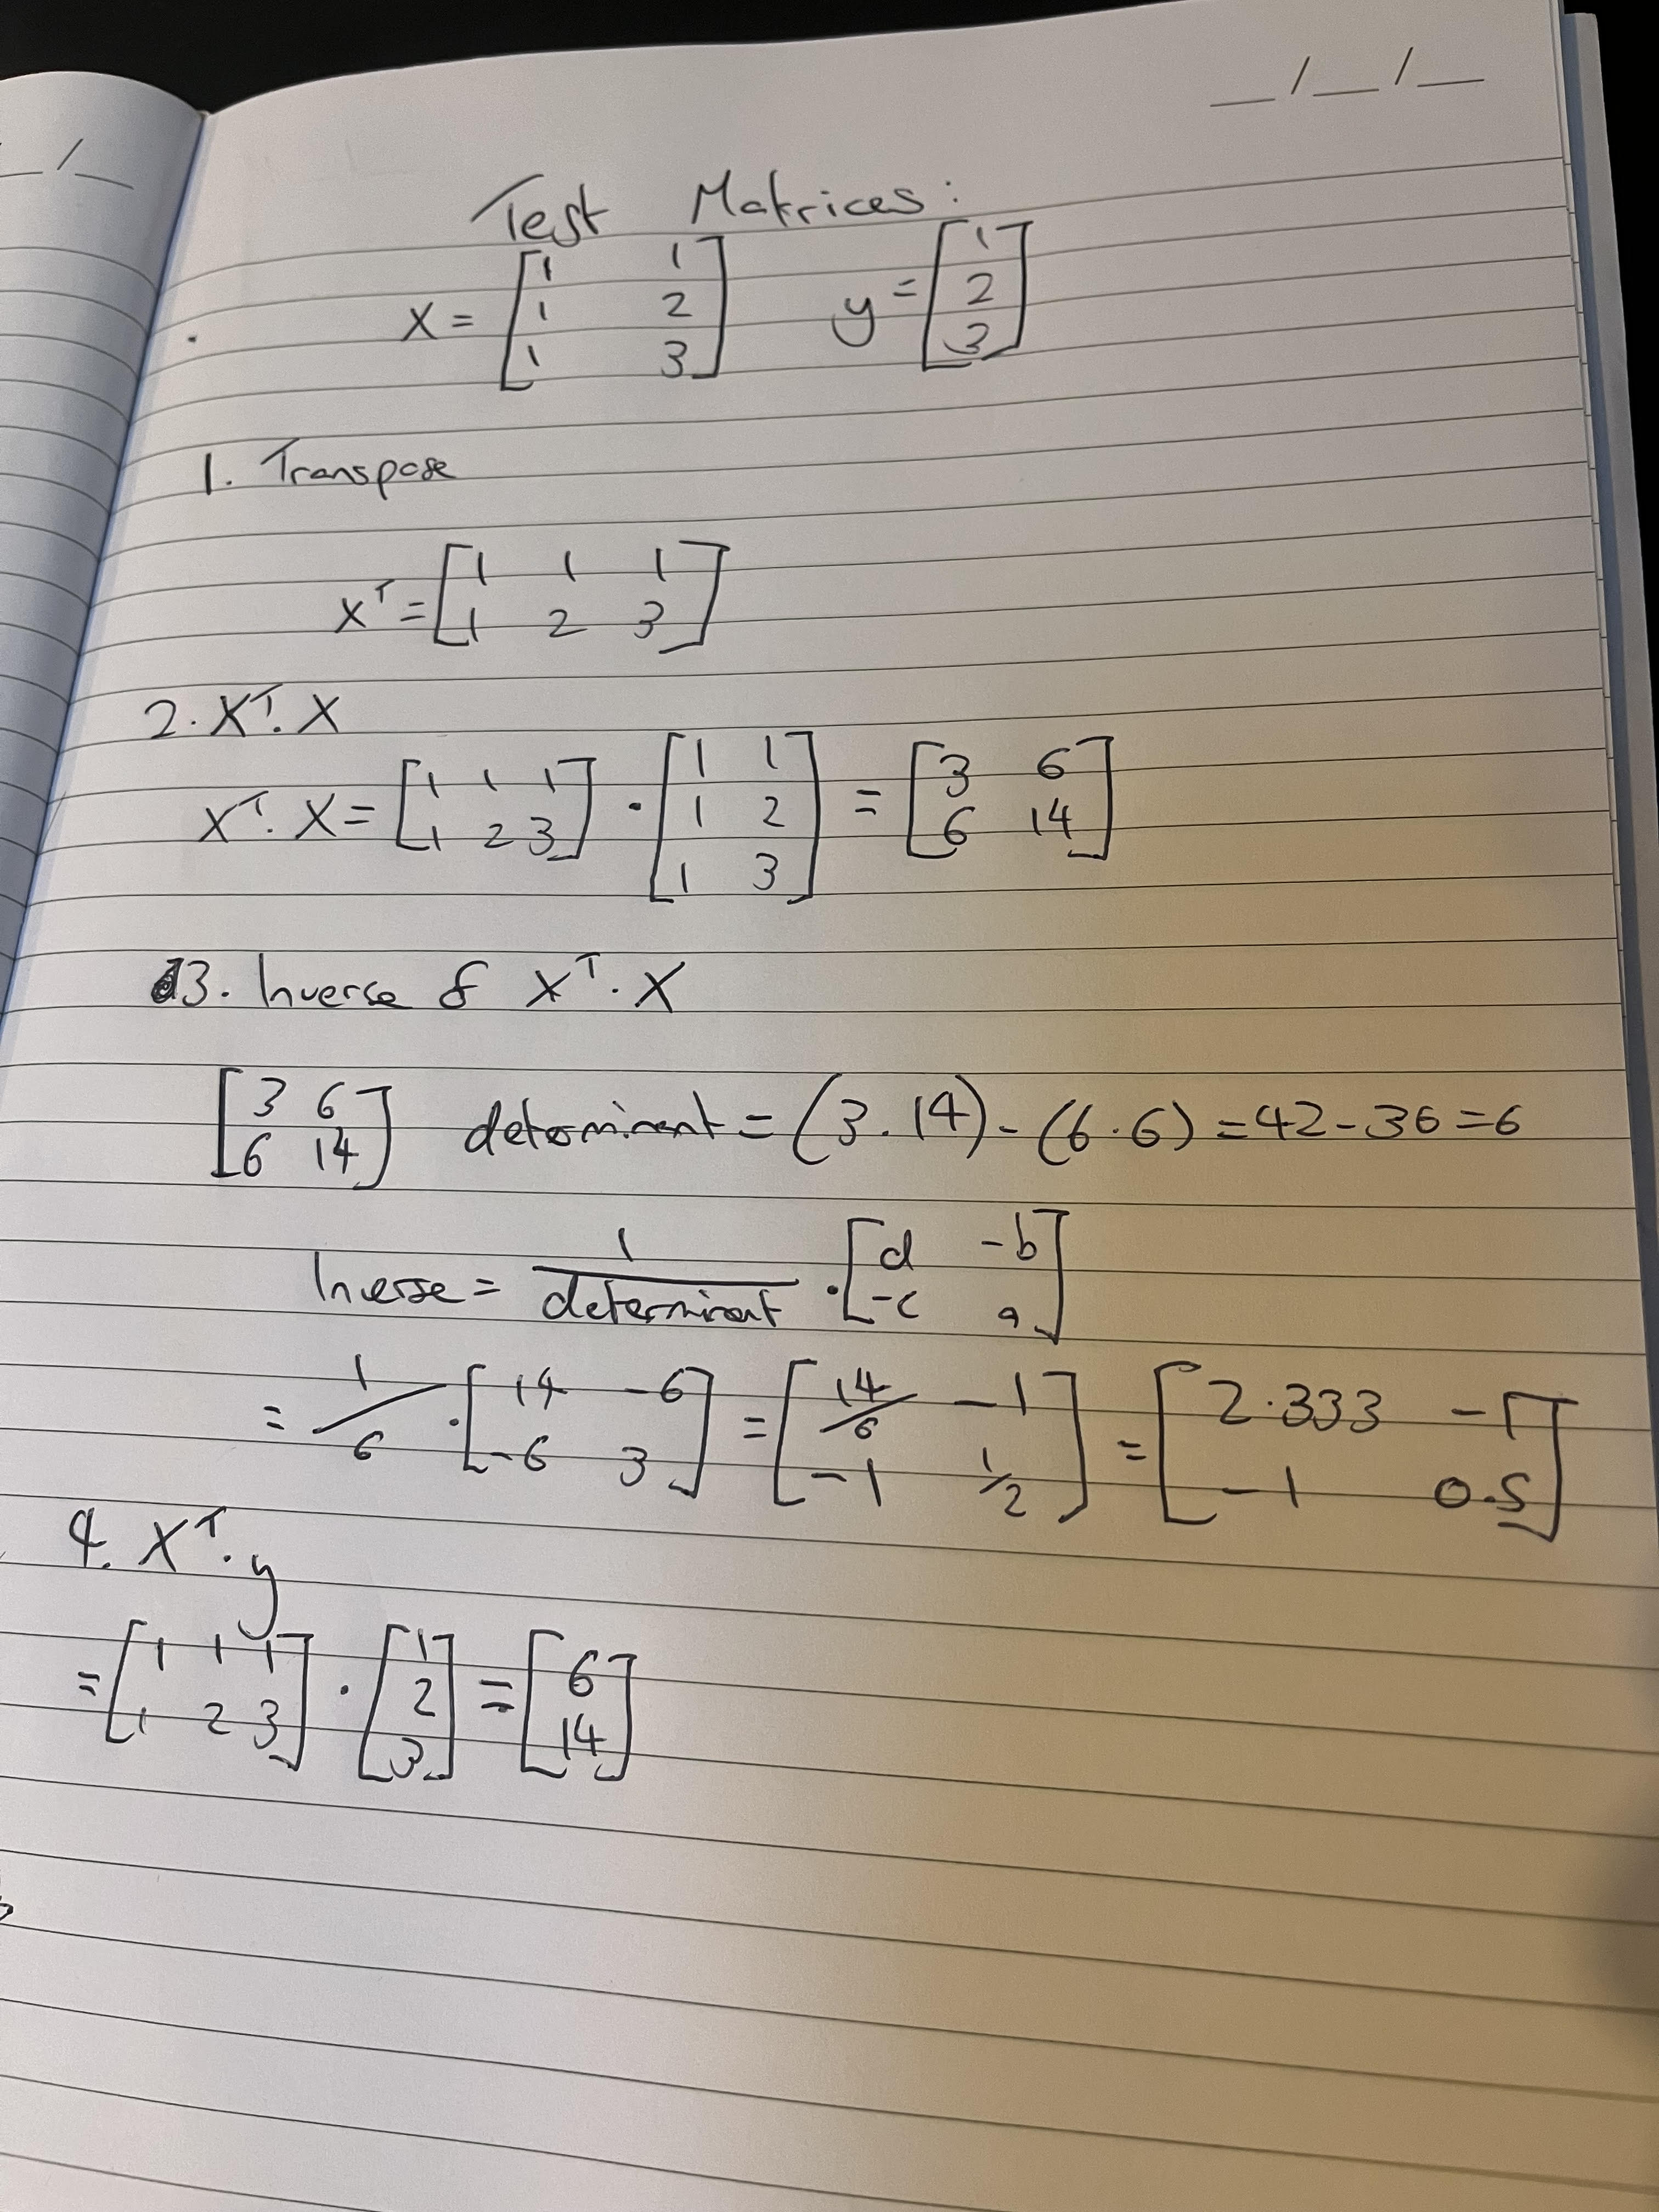
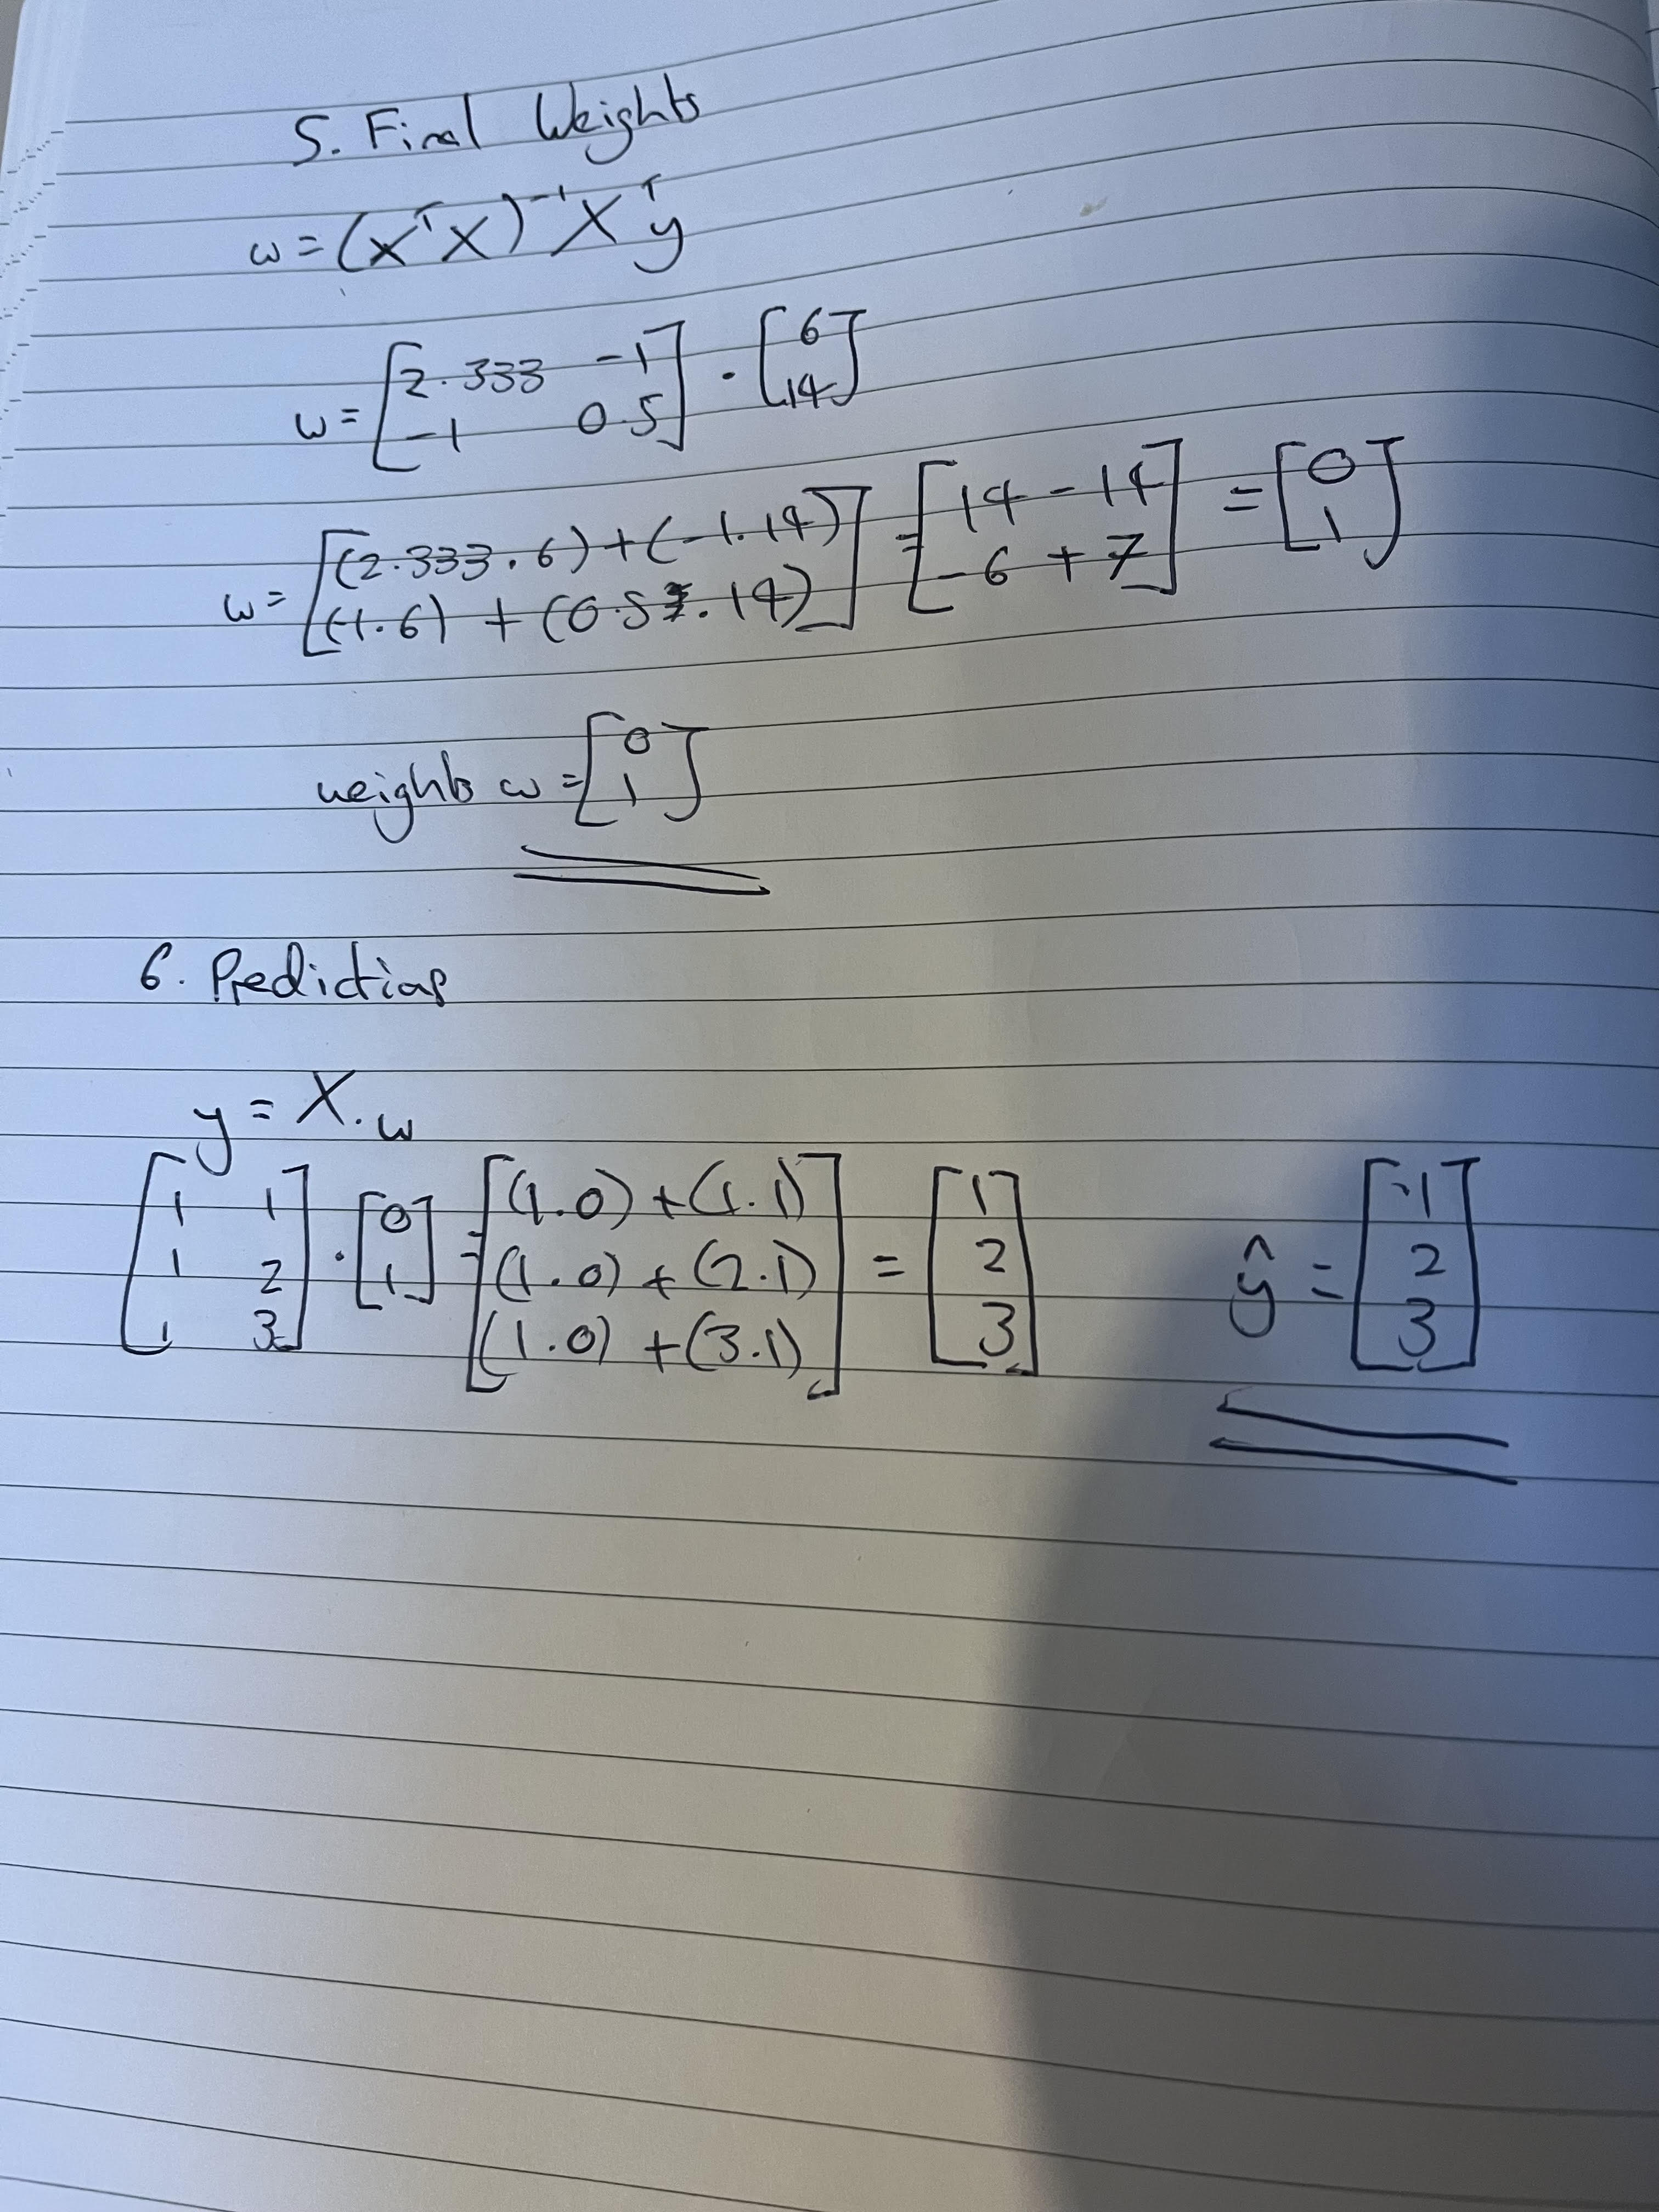

<hr style="border:2px solid gray"> </hr>

## Reflection

Write your reflection in below cell.

Task 1:
Explanation of functions:
1. matrix_transpose - swaps matrix rows with columns
2. matrix_multiply - zip() is used to columns of B with rows of A
3. matrix_inverse_2x2 - uses the formula for matrix inversion
4. fit - least squares formula
5. predict - uses weights w to predict outputs for inputs X

Peer Input:
Implementing Annabel's suggestion of using zip(), made the multiplication code cleaner. It streamlined the logic, which made it a lot easier to perform dot products between rows and columns, avoiding manually transposing the matrix.



TASK 2

In [43]:
class SimplePCA: #performs PCA and manual eigenvector calculations
    
    def __init__(self, data):
        self.X = data.values #Converts DataFrame to Numpy array
        
    def perform_pca(self, n_components=1):#perform PCA using Scikit-learn 
        
        self.pca = PCA(n_components=n_components)
        #PCA object created with n_components
        
        self.X_pca = self.pca.fit_transform(self.X)
        #Apply PCA to data

        
        self.X_projected = self.pca.inverse_transform(self.X_pca)
        #Project PCA-reduced data into original space

        
        print(f"PCA Components:\n{self.pca.components_}")
        #Print eigenvectors found by PCA

    def plot_pca(self): #plot original and PCA-reduced data

         plt.scatter(self.X[:,0], self.X[:,1], label='Original', alpha=0.5)
         #Scatter plot of original points
         
         plt.scatter(self.X_projected[:,0], self.X_projected[:,1], label='PCA Projected', alpha=0.8)
         #Scatter plot of PCA_reduced points

         plt.legend()
         #Plot legend

         plt.title("PCA Effect on Data")
         #Title of the plot

         plt.show()
         #Show plot

    def calculate_eigen(self): #Manually calculate eigenvectors and eigenvalues
          
          cov_matrix = np.cov(self.X.T)
          #Get covariance matrix of dataset
          
          eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
          #Perform eigenvalue decomposition to get eigenvalues and eigenvectors
          
          print(f"Eigenvectors:\n{eigenvectors}")
          #Print calculated eigenvectors (manually)
          
          return eigenvalues, eigenvectors






        



In [1]:
#Example dataset
import pandas as pd
data = pd.DataFrame({ #import pandas library for data manipulation
    'Data1': [2.5, 0.5, 2.6, 1.8, 3.2, 2.7, 2.1, 1.6, 1.8, 1,0], #value for first feature
    'Data2': [2.8, 0.7, 2.2, 2.3, 3.9, 2.1, 1.1, 1.9, 1.8, 0.3] #value for second feature
})

pca_analysis = SimplePCA(data) #create instance of SimplePCA class passing the data to it

pca_analysis.perform_pca(n_components=1) #reduce data to 1 principle component

pca_analysis.plot_pca() #Plot original data + PCA results

eigenvalues, eigenvectors = pca_analysis.calculate_eigen() #Calculate eigenvalues and aigenvalues of dataset

print("\nFirst PCA component (Scikit-learn):", pca_analysis.pca.components_[0]) #first principal component obtained from PCA
print("First Eigenvector (Numpy):", eigenvectors[:, 0]) #first eigenvector obtained from Numpy 

ValueError: All arrays must be of the same length

Note**** Part 1 went well as I had mrore time to work on it. Part 2 was a lot more rushed as I was settling into my new job. Time management will imrpove!